<a href="https://colab.research.google.com/github/antonum/sandbox/blob/pgvector/video_to_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!rm *.jpg

In [19]:

!wget https://www.sample-videos.com/video321/mp4/240/big_buck_bunny_240p_30mb.mp4

--2025-03-03 21:07:03--  https://www.sample-videos.com/video321/mp4/240/big_buck_bunny_240p_30mb.mp4
Resolving www.sample-videos.com (www.sample-videos.com)... 103.145.51.95
Connecting to www.sample-videos.com (www.sample-videos.com)|103.145.51.95|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31539436 (30M) [video/mp4]
Saving to: ‘big_buck_bunny_240p_30mb.mp4.1’

big_buck_bunny_240p 100%[===================>]  30.08M  7.21MB/s    in 4.2s    

2025-03-03 21:07:08 (7.21 MB/s) - ‘big_buck_bunny_240p_30mb.mp4.1’ saved [31539436/31539436]



In [ ]:
from IPython.display import HTML
from base64 import b64encode
mp4 = open('big_buck_bunny_240p_30mb.mp4','rb').read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
HTML("""
<video width=400 controls>
      <source src="%s" type="video/mp4">
</video>
""" % data_url)

# Clear output before saving!!!

In [21]:
import cv2
vidcap = cv2.VideoCapture('big_buck_bunny_240p_30mb.mp4')
success,image = vidcap.read()
count = 0
skip_frames = 50
frame = 0
while success:
  #print (count)
  if count % skip_frames == 0:
    cv2.imwrite("frame%05d.jpg" % frame, image)     # save frame as JPEG file
    success,image = vidcap.read()
    #print('Read a new frame: ',count, success)
    frame += 1
  else:
    success,image = vidcap.read()
  count += 1

In [22]:
# prompt: for each image generate vector embedding

import cv2
import numpy as np
from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2 # import MobileNetV2
from tensorflow.keras.preprocessing import image

# Load pre-trained MobileNetV2 model
model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')

def generate_embedding(image_path):
  img = image.load_img(image_path, target_size=(224, 224))
  x = image.img_to_array(img)
  x = np.expand_dims(x, axis=0)
  x = preprocess_input(x)
  embedding = model.predict(x)
  return embedding.flatten()



<ipython-input-22-603e482e3616>:10: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model = MobileNetV2(weights='imagenet', include_top=False, pooling='avg')


In [23]:
# length of embedding
#len(embedding)
#embedding

In [24]:
import psycopg2
from google.colab import userdata
#CONNECTION="postgres://tsdbadmin:xxxxxxx.yyyyy.tsdb.cloud.timescale.com:39966/tsdb?sslmode=require"
CONNECTION=userdata.get('TS_CONNECTION')
conn = psycopg2.connect(CONNECTION)
cursor = conn.cursor()

In [25]:

query = """
DROP TABLE IF EXISTS video_embeddings CASCADE;
"""
cursor.execute(query)
conn.commit()

In [26]:
#cursor.execute(query)
conn.commit()

In [27]:
query = """
-- create postgres table
CREATE TABLE video_embeddings (
   UUID UUID NOT NULL,
   x FLOAT,
   timestamp TIMESTAMPTZ NOT NULL,
   locationId INT,
   frameId INT,
   h FLOAT,
   eventId INT,
   videoPath TEXT,
   customerId INT,
   w FLOAT,
   receiveTime TIMESTAMPTZ,
   streamId INT,
   y FLOAT,
   vector VECTOR(1280), -- 1280-dimensional vector
   videoName TEXT,
   PRIMARY KEY (UUID, timestamp)
);
"""
cursor.execute(query)
conn.commit()

In [28]:
import uuid
import os
from datetime import datetime
# Construct the SQL query
query = """
              INSERT INTO video_embeddings (UUID, timestamp, vector, frameId, videoName)
              VALUES (%s, %s, %s, %s, %s)
          """
batch_size=10

image_files = [f for f in os.listdir('.') if f.startswith('frame') and f.endswith('.jpg')]


for image_file in image_files:
    embedding = generate_embedding(image_file)
    if embedding is not None:
        print(f"Embedding for {image_file}: {embedding}")
    # Prepare the data for insertion
    current_time = datetime.now()
    unique_uuid = uuid.uuid4()
    frame_id = int(image_file[5:-4])  # Extract frame ID from filename
    # Execute the query
    cursor.execute(query, (str(unique_uuid), current_time, embedding.tolist(), frame_id, "big_buck_bunny"))
    if frame_id % batch_size == 0:
      conn.commit()
conn.commit()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 973ms/step
Embedding for frame00019.jpg: [0.22533841 0.20959929 0.33396453 ... 0.03535697 0.2852489  1.5586663 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
Embedding for frame00074.jpg: [0.03307665 0.03936883 0.6898984  ... 0.09988832 0.40560758 0.37270695]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Embedding for frame00042.jpg: [0.00148941 0.24437854 0.7218745  ... 0.09361706 0.0485938  0.92055595]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Embedding for frame00018.jpg: [0.47282368 0.14042996 0.34235826 ... 0.0453708  0.904728   1.4808719 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
Embedding for frame00024.jpg: [0.43552548 0.17409556 0.9422422  ... 0.35600564 1.0655417  1.4607561 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Embedding for frame00057.jpg: [1.0529817  0.314719   0.95085067 ... 0.02089376 1.1535399  1.4790534 ]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Embedding for frame00031.jpg: [0.61987495 0.10685828 0.583671   ... 0.         0.05871757 1.5119078 ]
1/1 ━━━━━━━━━━━━━━━

In [29]:
import pandas as pd
def sql_results_to_df(cursor):
  columns = [desc[0] for desc in cursor.description]
  data = cursor.fetchall()
  df = pd.DataFrame(data, columns=columns)
  return df


In [30]:
# regular SQL query just to check things being inserted
query = """
SELECT timestamp, frameid, vector
FROM video_embeddings
LIMIT 5;
"""
cursor.execute(query)
sql_results_to_df(cursor)

,timestamp,frameid,vector
0,2025-03-03 21:07:22.167545+00:00,19,"[0.22533841,0.20959929,0.33396453,0.02629969,0..."
1,2025-03-03 21:07:22.593070+00:00,74,"[0.033076648,0.039368834,0.6898984,0.008153098..."
2,2025-03-03 21:07:22.788252+00:00,42,"[0.0014894058,0.24437854,0.7218745,0.002300632..."
3,2025-03-03 21:07:22.975700+00:00,18,"[0.47282368,0.14042996,0.34235826,0.00549223,0..."
4,2025-03-03 21:07:23.175016+00:00,24,"[0.43552548,0.17409556,0.9422422,0,0,0,1.24499..."


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


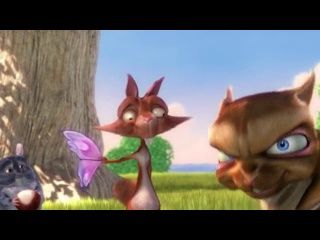

array([0.13117671, 0.3526034 , 0.8485941 , ..., 0.03752769, 0.3446392 ,
       0.272999  ], dtype=float32)

In [42]:
from IPython.display import Image, display
from tensorflow.keras.preprocessing import image


filename='frame00051.jpg' #rodent
#filename='frame00045.jpg' #bunny

# vector query against single embedding
apple_embedding = generate_embedding(filename)
display(Image(filename=filename))
apple_embedding

frame00051.jpg


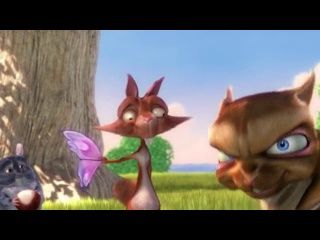

frame00049.jpg


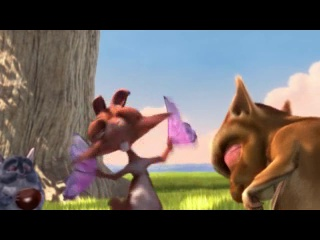

frame00050.jpg


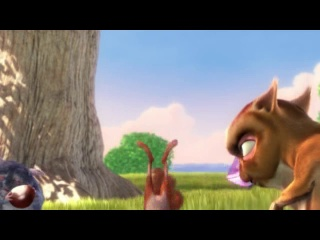

frame00046.jpg


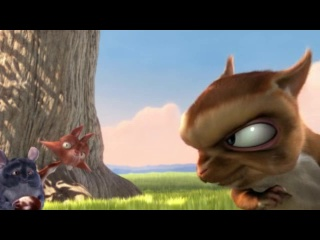

frame00042.jpg


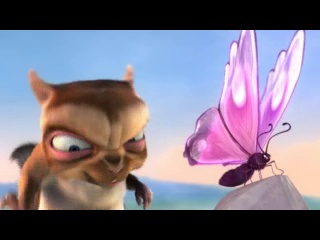

In [43]:
query = """
SELECT timestamp, frameid, vector,
vector <=> %s AS distance
FROM video_embeddings
ORDER BY distance
LIMIT 5;
"""
cursor.execute(query, [str(apple_embedding.tolist())])
df=sql_results_to_df(cursor)

from IPython.display import Image, display

# Iterate over the 'frameid' column and format it
df['frameid'] = df['frameid'].apply(lambda x: f'frame{x:05d}.jpg')


# Display the images
for filename in df['frameid']:
    print(filename)
    display(Image(filename=filename))